In [1]:
#Creating NumPy arrays 
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 2, 3, 4, 5, 6], dtype=float)
Y = np.array([0, 0, 1, 1, 1, 1], dtype=float)

print("X:", X)
print("Y:", Y)

X: [1. 2. 3. 4. 5. 6.]
Y: [0. 0. 1. 1. 1. 1.]


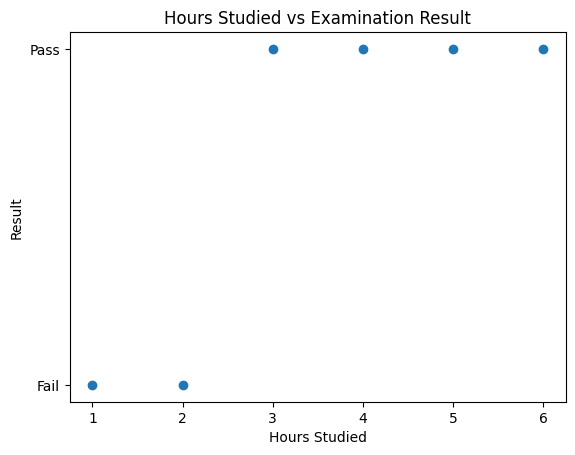

In [2]:
# Display Dataset using a scatter plot
plt.scatter(X, Y)
plt.xlabel("Hours Studied")
plt.ylabel("Result")
plt.yticks([0, 1], ["Fail", "Pass"])
plt.title("Hours Studied vs Examination Result")
plt.show()

In [4]:
# Implementing sigmoid function from scratch using numpy
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [5]:
# Initializing values
theta0 = 0
theta1 = 0

In [6]:
# Predicted Probabilities
z = theta0 + theta1 * X
probabilities = sigmoid(z)

print(probabilities)

[0.5 0.5 0.5 0.5 0.5 0.5]


In [7]:
# Implementing log loss function from scratch
def log_loss(y, p):
    epsilon = 1e-15
    p = np.clip(p, epsilon, 1 - epsilon)

    return -np.mean(
        y * np.log(p) +
        (1 - y) * np.log(1 - p)
    )

In [8]:
# Displaying initial cost
initial_probabilities = sigmoid(theta0 + theta1 * X)

initial_cost = log_loss(Y, initial_probabilities)

print("Initial Log-Loss:", initial_cost)

Initial Log-Loss: 0.6931471805599453


In [9]:
# Set a suitable learning rate and initialize and to zero.
theta0 = 0.0
theta1 = 0.0

learning_rate = 0.1
iterations = 5000

cost_history = []

m = len(Y)

for i in range(iterations):

    # Step 1: Calculate linear score
    z = theta0 + theta1 * X

    # Step 2: Convert to probabilities
    probabilities = sigmoid(z)

    # Step 3: Calculate cost
    cost = log_loss(Y, probabilities)
    cost_history.append(cost)

    # Step 4: Calculate gradients
    gradient0 = np.mean(probabilities - Y)
    gradient1 = np.mean((probabilities - Y) * X)

    # Step 5: Update parameters
    theta0 = theta0 - learning_rate * gradient0
    theta1 = theta1 - learning_rate * gradient1

print("Final theta0:", theta0)
print("Final theta1:", theta1)
print("Final cost:", cost_history[-1])

Final theta0: -9.731632850221068
Final theta1: 3.9753167619356784
Final cost: 0.04444551763864804


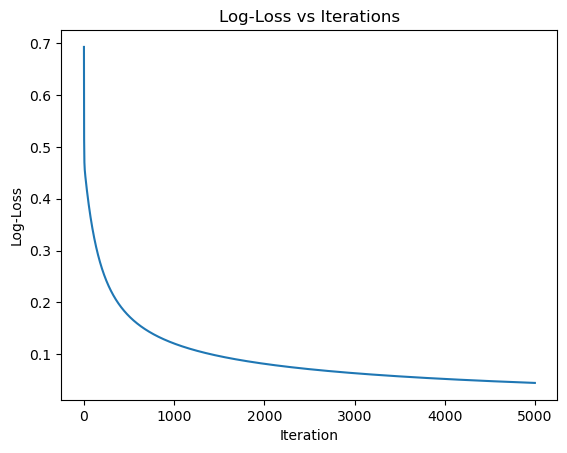

In [10]:
# Plot iteration number against log-loss
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Log-Loss")
plt.title("Log-Loss vs Iterations")
plt.show()

In [11]:
# Logistic regression prediction from scratch
def predict(x, theta0, theta1, threshold=0.5):

    probability = sigmoid(theta0 + theta1 * x)

    if probability >= threshold:
        prediction = 1
    else:
        prediction = 0

    return probability, prediction

In [12]:
# Result for a student who studied 2.5 hours
probability, prediction = predict(
    2.5,
    theta0,
    theta1,
    threshold=0.5
)

print("Probability:", probability)
print("Predicted class:", prediction)

Probability: 0.5514816708244734
Predicted class: 1


In [13]:
# Changing the threshold to 0.7
probability, prediction = predict(
    2.5,
    theta0,
    theta1,
    threshold=0.7
)

print("Probability:", probability)
print("Predicted class:", prediction)

Probability: 0.5514816708244734
Predicted class: 0


In [14]:
# Verify Logistic Regression Using Scikit-learn
from sklearn.linear_model import LogisticRegression

X_2d = X.reshape(-1, 1)

model = LogisticRegression()

model.fit(X_2d, Y.astype(int))

new_student = np.array([[2.5]])

probability = model.predict_proba(new_student)[0][1]
prediction = model.predict(new_student)[0]

print("Probability of Pass:", probability)
print("Predicted class:", prediction)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Probability of Pass: 0.5259872612927811
Predicted class: 1
Intercept: [-2.59584271]
Coefficient: [[1.0799542]]


In [15]:
# Calculate Euclidean Distance
# 1. Create training dataset

X_train = np.array([
    [1, 1],
    [2, 1.5],
    [2, 3],
    [4, 5],
    [5, 4.5],
    [5, 2.5]
], dtype=float)

y_train = np.array([0, 0, 0, 1, 1, 1])

students = np.array(["A", "B", "C", "D", "E", "F"])

Q = np.array([4, 2], dtype=float)

In [3]:
# Euclidean distance function
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

In [17]:
# Calculating the distance from Q to every training observation
distances = []

for point in X_train:
    distance = euclidean_distance(point, Q)
    distances.append(distance)

distances = np.array(distances)

for student, distance in zip(students, distances):
    print(student, ":", round(distance, 3))

A : 3.162
B : 2.062
C : 2.236
D : 3.0
E : 2.693
F : 1.118


In [18]:
# Sort the observations
sorted_indices = np.argsort(distances)

for index in sorted_indices:
    print(
        students[index],
        "Distance =", round(distances[index], 3),
        "Class =", y_train[index]
    )

F Distance = 1.118 Class = 1
B Distance = 2.062 Class = 0
C Distance = 2.236 Class = 0
E Distance = 2.693 Class = 1
D Distance = 3.0 Class = 1
A Distance = 3.162 Class = 0


In [19]:
# Find k Nearest Neighbors & Majority Vote
k = 3

nearest_indices = sorted_indices[:k]

print("Three nearest neighbors:")

for index in nearest_indices:
    print(
        students[index],
        "Distance:", round(distances[index], 3),
        "Class:", y_train[index]
    )

Three nearest neighbors:
F Distance: 1.118 Class: 1
B Distance: 2.062 Class: 0
C Distance: 2.236 Class: 0


In [20]:
for k in [1, 3, 5]:

    nearest_indices = sorted_indices[:k]

    nearest_labels = y_train[nearest_indices]

    prediction = np.bincount(nearest_labels).argmax()

    print("k =", k)
    print("Labels:", nearest_labels)
    print("Prediction:", prediction)

k = 1
Labels: [1]
Prediction: 1
k = 3
Labels: [1 0 0]
Prediction: 0
k = 5
Labels: [1 0 0 1 1]
Prediction: 1


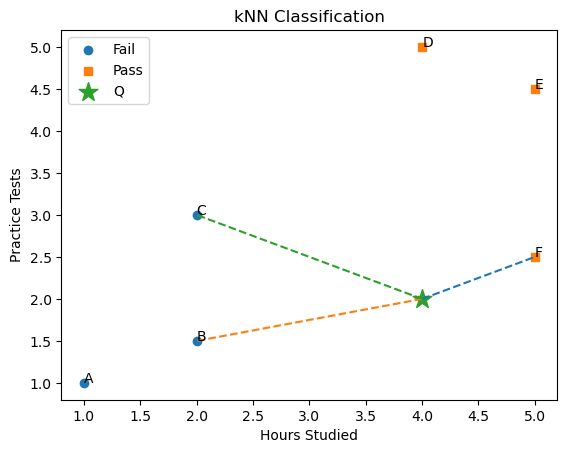

In [21]:
# Visualize kNN
plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    marker="o",
    label="Fail"
)

plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    marker="s",
    label="Pass"
)

plt.scatter(
    Q[0],
    Q[1],
    marker="*",
    s=200,
    label="Q"
)

# Highlight the nearest 3
nearest_indices = sorted_indices[:3]

for index in nearest_indices:
    plt.plot(
        [Q[0], X_train[index, 0]],
        [Q[1], X_train[index, 1]],
        linestyle="--"
    )

for i, student in enumerate(students):
    plt.annotate(
        student,
        (X_train[i, 0], X_train[i, 1])
    )

plt.xlabel("Hours Studied")
plt.ylabel("Practice Tests")
plt.title("kNN Classification")
plt.legend()
plt.show()

In [27]:
# Complete kNN Algorithm
def knn_predict(X_train, y_train, query, k):

    # Step 1: Calculate distances
    distances = []

    for point in X_train:
        distance = np.sqrt(
            np.sum((point - query) ** 2)
        )

        distances.append(distance)

    distances = np.array(distances)

    # Step 2: Sort distances
    sorted_indices = np.argsort(distances)

    # Step 3: Select k nearest neighbors
    nearest_indices = sorted_indices[:k]

    # Step 4: Obtain labels
    nearest_labels = y_train[nearest_indices]

    # Step 5: Majority voting
    prediction = np.bincount(
        nearest_labels
    ).argmax()

    # Step 6: Return prediction
    return prediction

In [24]:
# Test it
prediction = knn_predict(
    X_train,
    y_train,
    Q,
    3
)

print("Prediction:", prediction)

Prediction: 0


In [25]:
# Verify 
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

prediction = knn.predict([[4, 2]])

print("Prediction:", prediction[0])

Prediction: 0


In [29]:
# Standardize this kNN dataset
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_train)

Q_scaled = scaler.transform([[4, 2]])

knn_scaled = KNeighborsClassifier(n_neighbors=3)

knn_scaled.fit(X_scaled, y_train)

prediction = knn_scaled.predict(Q_scaled)

print("Prediction after scaling:", prediction[0])

Prediction after scaling: 0
